In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

## 13-3 程式範例：影像分割實作

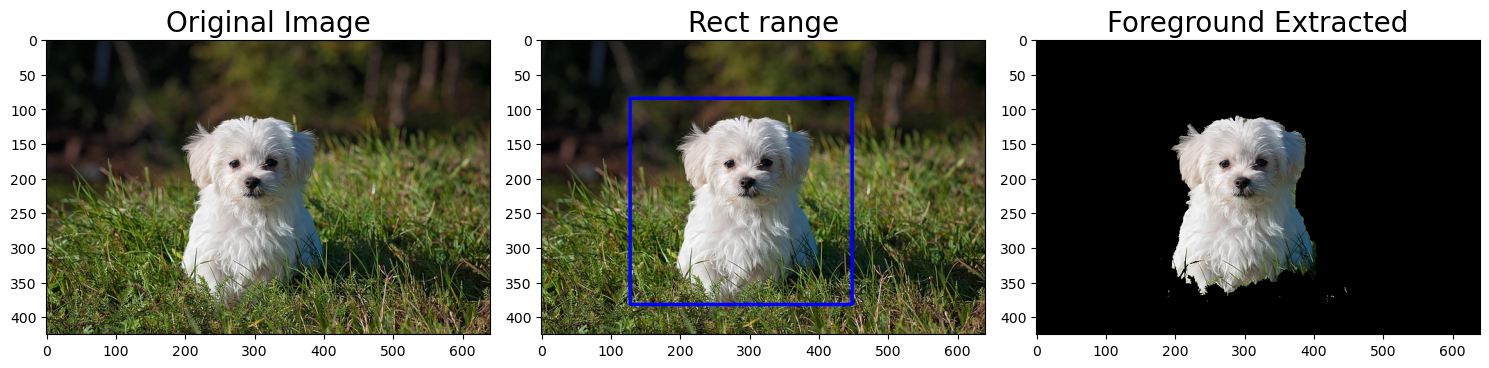

In [2]:
# 載入影像
img = cv2.imread('sample/dog.jpg')

# 獲取影像大小
height, width = img.shape[:2]

# 初始化遮罩、大小與輸入影像相同
mask = np.zeros((height, width), dtype=np.uint8)

# 初始化背景和前景模型
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# 定義初始矩形框（手動調整座標，讓框能完整包含整隻狗）
rect_x = int(width * 0.2)
rect_y = int(height * 0.2)
rect_w = int(width * 0.5)
rect_h = int(height * 0.7)
rect = (rect_x, rect_y, rect_w, rect_h)

# 畫出初始框對應原圖的位置
top_left = (rect_x, rect_y)
bottom_right = (rect_x + rect_w, rect_y + rect_h)
img_rect = img.copy()
cv2.rectangle(img_rect, top_left, bottom_right, (255, 0, 0), 3)

# 使用 cv2.grabCut 進行分割
cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

# 將遮罩結果轉為二元影像（前景為 1，背景為 0）
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# 使用遮罩提取前景
img_foreground = img * mask2[:, :, np.newaxis]

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(  
    'Original Image', img,    
    'Rect range', img_rect,
    'Foreground Extracted', img_foreground
)

### 13-E-1 範例結果：觀察去背的效果

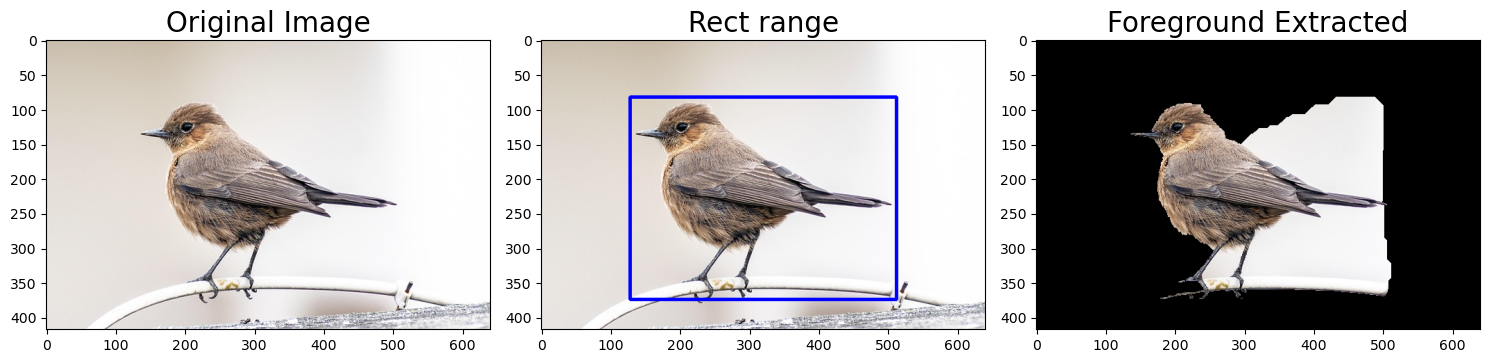

In [3]:
# 載入影像
img = cv2.imread('sample/bird.jpg')

# 獲取影像大小
height, width = img.shape[:2]

# 初始化遮罩、大小與輸入影像相同
mask = np.zeros((height, width), dtype=np.uint8)
# 初始化背景和前景模型
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# 定義初始矩形框
# 此處 height 改用 0.7（前一節為 0.6），讓矩形框能完整包含小鳥的腳
rect_x = int(width * 0.2)
rect_y = int(height * 0.2)
rect_w = int(width * 0.6)
rect_h = int(height * 0.7)
rect = (rect_x, rect_y, rect_w, rect_h)

# 畫出初始框對應原圖的位置
top_left = (rect_x, rect_y)
bottom_right = (rect_x + rect_w, rect_y + rect_h)
img_rect = img.copy()
cv2.rectangle(img_rect, top_left, bottom_right, (255, 0, 0), 3)

# 使用 cv2.grabCut 進行分割
cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

# 將遮罩結果轉為二元影像（前景為 1，背景為 0）
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# 使用遮罩提取前景
img_foreground = img * mask2[:, :, np.newaxis]

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Original Image', img,
    'Rect range', img_rect,
    'Foreground Extracted', img_foreground,
)

### 13-E-2 影像分割的侷限：可能不存在完美的矩形框

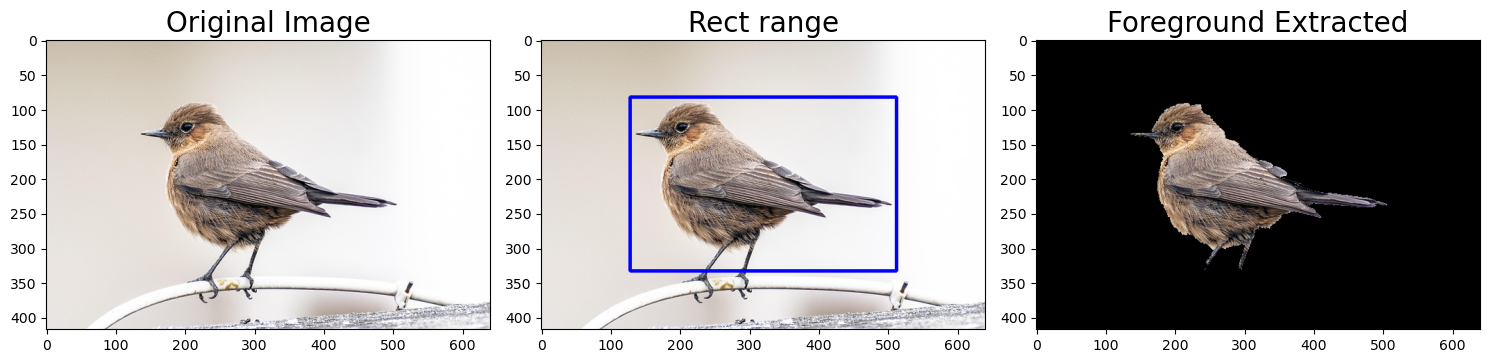

In [4]:
# 載入影像
img = cv2.imread('sample/bird.jpg')

# 獲取影像大小
height, width = img.shape[:2]

# 初始化遮罩、大小與輸入影像相同
mask = np.zeros((height, width), dtype=np.uint8)
# 初始化背景和前景模型
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# 定義初始矩形框
# 此處 height 使用 0.6，但會切到小鳥的腳
rect_x = int(width * 0.2)
rect_y = int(height * 0.2)
rect_w = int(width * 0.6)
rect_h = int(height * 0.6)
rect = (rect_x, rect_y, rect_w, rect_h)

# 畫出初始框對應原圖的位置
top_left = (rect_x, rect_y)
bottom_right = (rect_x + rect_w, rect_y + rect_h)
img_rect = img.copy()
cv2.rectangle(img_rect, top_left, bottom_right, (255, 0, 0), 3)

# 使用 cv2.grabCut 進行分割
cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

# 將遮罩結果轉為二元影像（前景為 1，背景為 0）
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# 使用遮罩提取前景
img_foreground = img * mask2[:, :, np.newaxis]

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Original Image', img,
    'Rect range', img_rect,
    'Foreground Extracted', img_foreground,
)